# 3. T맵 내비게이션 유입 분석 (보조)

**데이터**: T맵 OD (2025.01~2026.04)
**장점**: 관광지 이름이 직접 나옴 → 방송 소개 관광지 정확히 특정 가능
**지표**: 일별 방문건수, 체류시간, 출발지(원거리 유입 여부)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import TMAP_DIR, BROADCAST_DIR, read_csv_auto

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 3.1 T맵 데이터 로드

In [2]:
# 전체 T맵 데이터 로드 (월별 파일)
dfs = []
for f in sorted(TMAP_DIR.glob('as_tmap_od_*.csv')):
    df = read_csv_auto(f)
    dfs.append(df)
    print(f"{f.name}: {len(df):,}행")

tmap = pd.concat(dfs, ignore_index=True)
print(f"\n총: {len(tmap):,}행")

# 날짜 변환
tmap['date'] = pd.to_datetime(tmap['drv_ymd'], format='%Y%m%d')
tmap['ym'] = tmap['date'].dt.to_period('M')
tmap.head()

as_tmap_od_202501.csv: 26,311행
as_tmap_od_202502.csv: 26,393행
as_tmap_od_202503.csv: 31,735행
as_tmap_od_202504.csv: 32,144행
as_tmap_od_202505.csv: 34,213행
as_tmap_od_202506.csv: 31,516행
as_tmap_od_202507.csv: 45,257행
as_tmap_od_202508.csv: 45,438행
as_tmap_od_202509.csv: 43,298행
as_tmap_od_202510.csv: 72,316행
as_tmap_od_202511.csv: 49,886행
as_tmap_od_202512.csv: 43,129행
as_tmap_od_202601.csv: 34,290행
as_tmap_od_202602.csv: 31,348행
as_tmap_od_202603.csv: 37,545행
as_tmap_od_202604.csv: 38,527행

총: 623,346행


,drv_ymd,frst_dptre_ctpv_nm,frst_dptre_sgg_nm,dstn_nm,dstn_coord_x,dstn_coord_y,dstn_ctpv_nm,dstn_sgg_nm,dstn_dong_nm,dstn_addr,...,THRD_ARVL_HR,FRST_NEXT_DSTN_NM,SCND_NEXT_DSTN_NM,THRD_NEXT_DSTN_NM,FRST_NEXT_DSTN_CNT,SCND_NEXT_DSTN_CNT,THRD_NEXT_DSTN_CNT,CRTR_YM,date,ym
0,20250101.0,경기도,성남시 분당구,파라다이스스파도고,126.885860,36.766166,충청남도,아산시,선장면,충남 아산시 선장면 신성리 260-0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,2025-01
1,20250101.0,경기도,평택시,신정호유원지,126.980578,36.775460,충청남도,아산시,온양4동,충남 아산시 방축동 685-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,2025-01
2,20250101.0,경기도,평택시,영인산초입주차장,126.957834,36.850754,충청남도,아산시,영인면,충남 아산시 영인면 아산리 58-43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,2025-01
3,20250101.0,충청남도,당진시,외암리민속마을,127.017960,36.729976,충청남도,아산시,송악면,충남 아산시 송악면 외암리 84-0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,2025-01
4,20250101.0,충청남도,아산시,N마트/아산신창점,126.956999,36.792182,충청남도,아산시,신창면,충남 아산시 신창면 남성리 101-3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,2025-01


## 3.2 방송 촬영 관광지 특정

In [3]:
# broadcast_locations에서 촬영지 목록
locations = read_csv_auto(BROADCAST_DIR / 'broadcast_locations.csv')
filmed_spots = locations['촬영지명'].dropna().unique().tolist()
print(f"촬영지 {len(filmed_spots)}곳:")
for s in filmed_spots:
    print(f"  {s}")

# T맵 목적지에서 촬영지 매칭
print(f"\nT맵 목적지 유니크: {tmap['dstn_nm'].nunique()}개")

# 키워드 매칭
spot_keywords = {
    '신정호': ['신정호'],
    '현충사': ['현충사'],
    '외암민속마을': ['외암', '민속마을'],
    '온양온천': ['온양온천', '온천'],
    '곡교천': ['곡교천', '은행나무'],
    '피나클랜드': ['피나클'],
    '영인산': ['영인산'],
    '온양온천시장': ['온양.*시장', '온천.*시장'],
    '이순신관광체험센터': ['이순신.*체험', '관광체험'],
    '도고파라다이스': ['도고', '파라다이스'],
    '스파포레': ['스파포레'],
}

def match_spot(name, keywords_dict):
    import re
    for spot, keywords in keywords_dict.items():
        for kw in keywords:
            if re.search(kw, str(name)):
                return spot
    return None

tmap['matched_spot'] = tmap['dstn_nm'].apply(lambda x: match_spot(x, spot_keywords))

matched = tmap[tmap['matched_spot'].notna()]
print(f"\n매칭된 행: {len(matched):,} / {len(tmap):,}")
print(f"\n매칭된 관광지별 건수:")
display(matched.groupby('matched_spot')['vst_cnt'].sum().sort_values(ascending=False))

촬영지 20곳:
  신정호 잔디광장
  아산시 일원
  온양온천역 광장
  족욕체험장
  온양온천 전통시장
  곡교천 은행나무길
  이순신 관광체험센터
  현충사
  피나클랜드
  아산시 주요명소
  신정호정원
  영인산
  외암민속마을
  온양온천시장
  온양온천(왕실온천/노천탕)
  도고파라다이스
  아산스파포레
  온천
  캠핑장
  온양온천역 주무대

T맵 목적지 유니크: 9101개

매칭된 행: 41,695 / 623,346

매칭된 관광지별 건수:


matched_spot
신정호          84770.0
온양온천         64626.0
현충사          62120.0
도고파라다이스      55184.0
피나클랜드        28646.0
외암민속마을       26948.0
곡교천          20816.0
영인산          15635.0
스파포레          1837.0
온양온천시장        1463.0
이순신관광체험센터      281.0
Name: vst_cnt, dtype: float64

## 3.3 촬영 관광지 일별 방문 추이

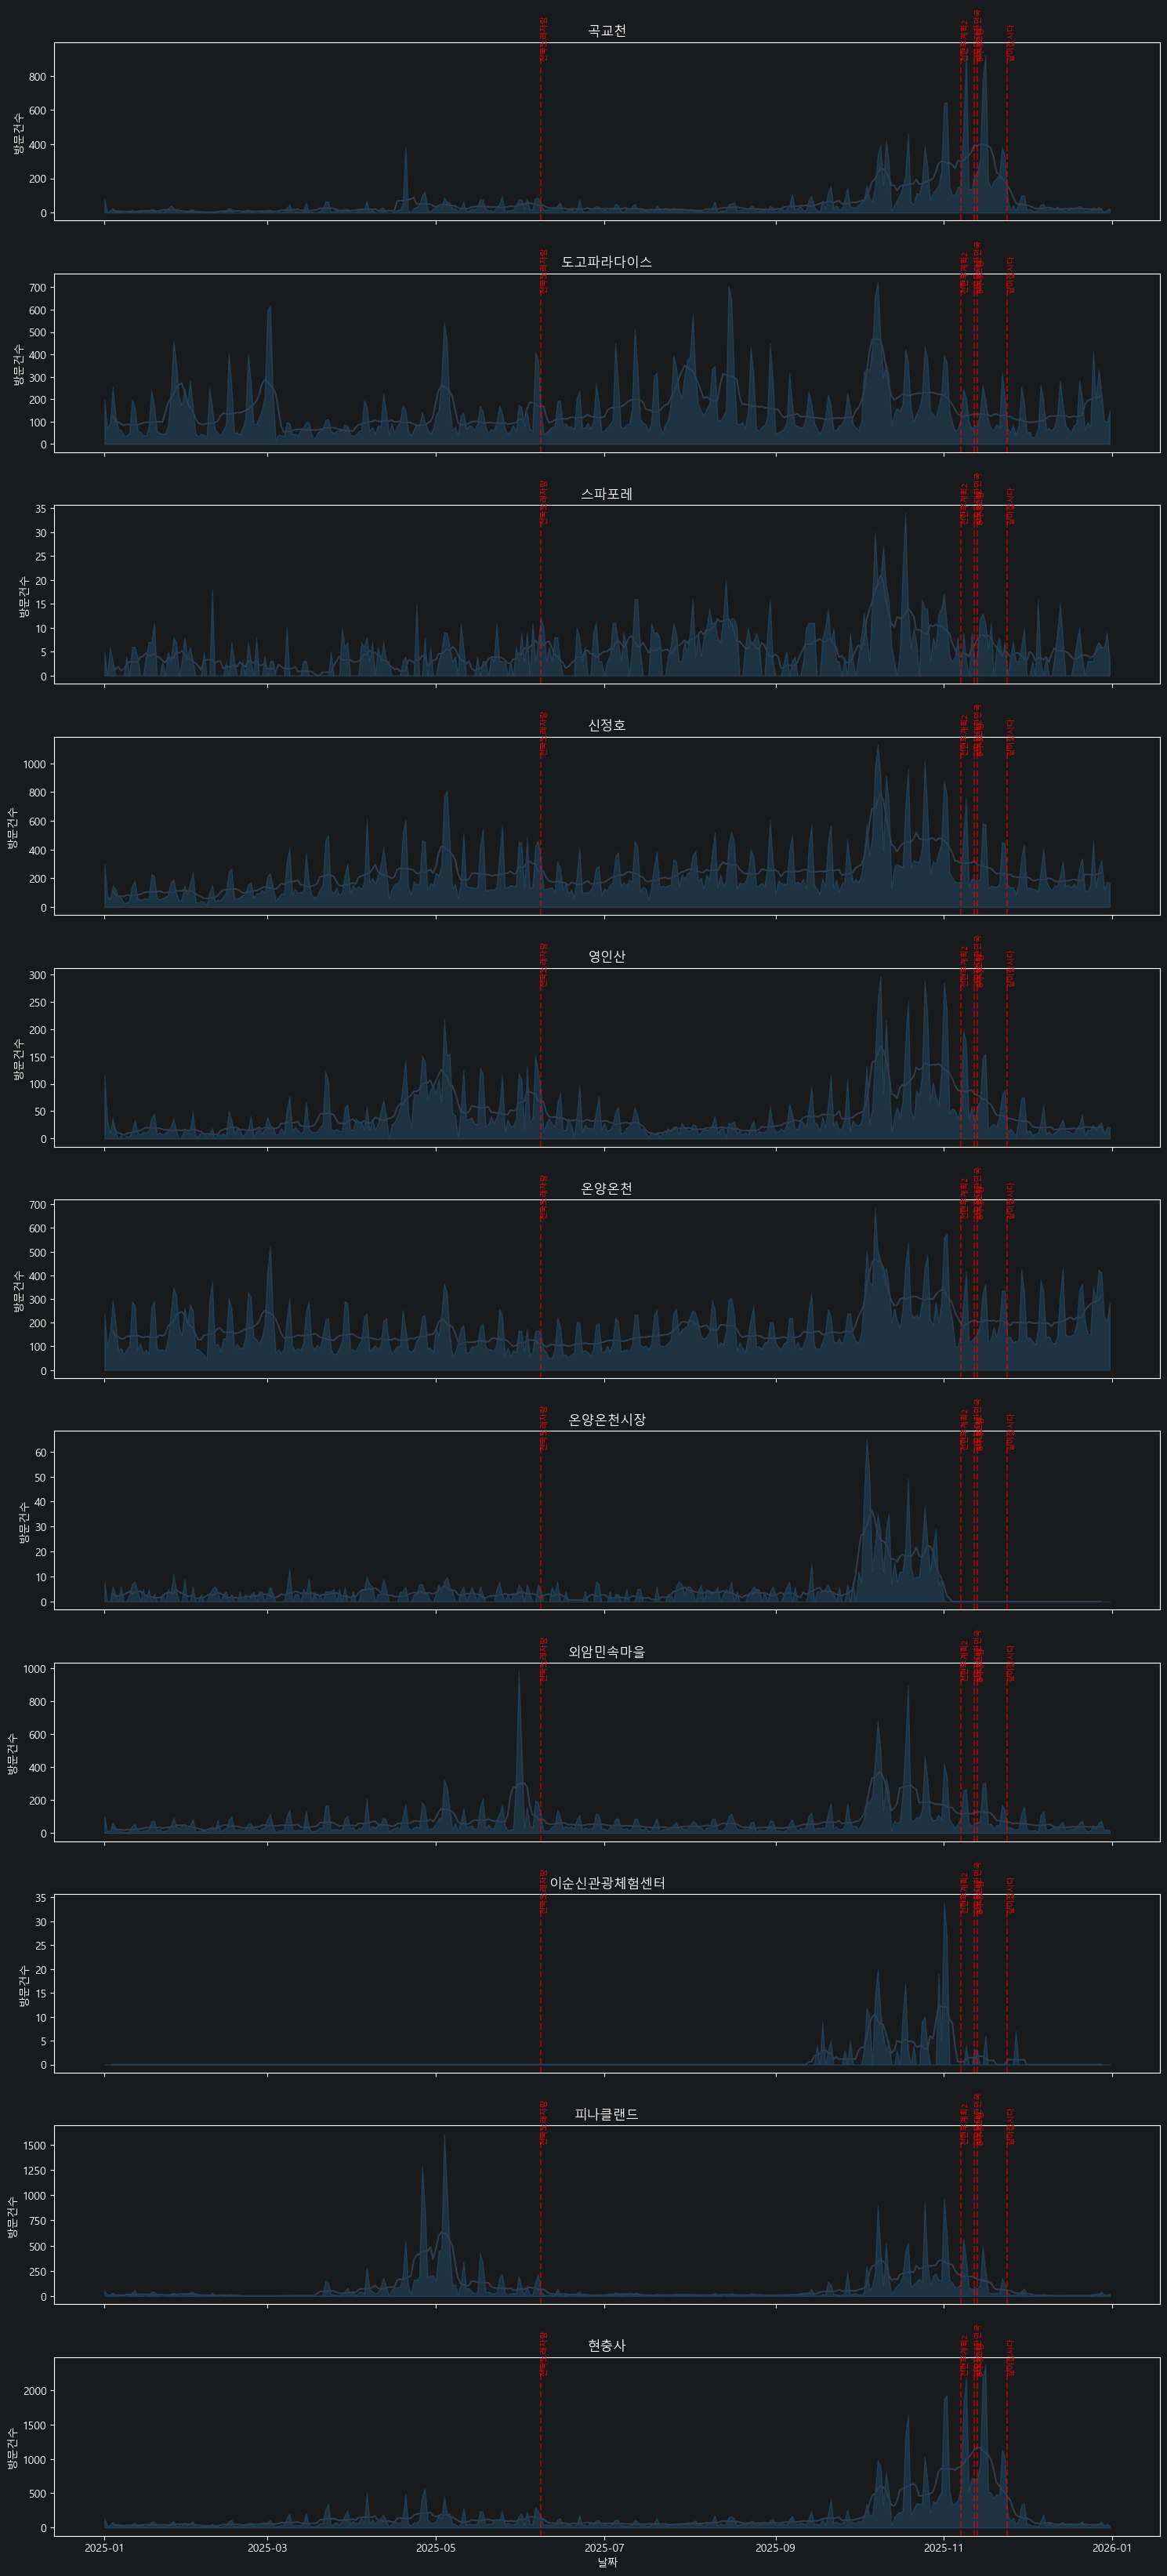

In [4]:
# 촬영 관광지 일별 방문건수
spot_daily = matched.groupby(['date', 'matched_spot'])['vst_cnt'].sum().unstack('matched_spot').fillna(0)

# 비촬영 관광지 (매칭 안 된 것) 일별 합계
unmatched = tmap[tmap['matched_spot'].isna()]
control_daily = unmatched.groupby('date')['vst_cnt'].sum()
control_daily.name = 'control_기타관광지'

fig, axes = plt.subplots(len(spot_daily.columns), 1, figsize=(15, 3*len(spot_daily.columns)), sharex=True)
if len(spot_daily.columns) == 1:
    axes = [axes]

broadcast_air_dates = {
    '전국노래자랑': pd.Timestamp('2025-06-08'),
    '전현무계획2': pd.Timestamp('2025-11-07'),
    '굿모닝대한민국': pd.Timestamp('2025-11-12'),
    '6시내고향': pd.Timestamp('2025-11-13'),
    '같이삽시다': pd.Timestamp('2025-11-24'),
    '뛰어야산다2': pd.Timestamp('2026-01-12'),
    '황제파워': pd.Timestamp('2026-05-09'),
}

for ax, spot in zip(axes, spot_daily.columns):
    # 7일 이동평균
    raw = spot_daily[spot]
    ma7 = raw.rolling(7, center=True).mean()
    
    ax.fill_between(raw.index, raw.values, alpha=0.2, color='#3498db')
    ax.plot(ma7.index, ma7.values, color='#2c3e50', linewidth=1.5, label='7일 이동평균')
    
    # 방송 시점 표시
    for name, dt in broadcast_air_dates.items():
        if dt >= raw.index.min() and dt <= raw.index.max():
            ax.axvline(dt, color='red', linestyle='--', alpha=0.5)
            ax.text(dt, ax.get_ylim()[1]*0.9, name, fontsize=7, rotation=90, color='red')
    
    ax.set_title(spot)
    ax.set_ylabel('방문건수')

plt.xlabel('날짜')
plt.tight_layout()
plt.show()

## 3.4 출발지 분석: 방송 후 원거리 유입 증가 여부

In [5]:
# 출발지 시도별 분포: 방송 전 vs 후
def origin_comparison(spot_name, air_date, pre_days=30, post_days=30):
    """특정 관광지의 방송 전후 출발지 분포 비교"""
    spot_data = matched[matched['matched_spot'] == spot_name].copy()
    
    pre_mask = (spot_data['date'] >= air_date - pd.Timedelta(days=pre_days)) & (spot_data['date'] < air_date)
    post_mask = (spot_data['date'] >= air_date) & (spot_data['date'] < air_date + pd.Timedelta(days=post_days))
    
    pre = spot_data[pre_mask].groupby('frst_dptre_ctpv_nm')['vst_cnt'].sum()
    post = spot_data[post_mask].groupby('frst_dptre_ctpv_nm')['vst_cnt'].sum()
    
    comp = pd.DataFrame({'방송전': pre, '방송후': post}).fillna(0)
    comp['변화율'] = ((comp['방송후'] - comp['방송전']) / comp['방송전'].replace(0, np.nan) * 100).round(1)
    comp = comp.sort_values('방송후', ascending=False)
    
    print(f"\n{spot_name} - 방송 전후 출발지 비교 (기준: {air_date.date()})")
    display(comp.head(15))
    
    # 충남 내 vs 충남 외 비율 변화
    local_pre = pre.get('충청남도', 0) / pre.sum() * 100 if pre.sum() > 0 else 0
    local_post = post.get('충청남도', 0) / post.sum() * 100 if post.sum() > 0 else 0
    print(f"충남 비율: {local_pre:.1f}% → {local_post:.1f}%")
    print(f"원거리(충남 외) 비율: {100-local_pre:.1f}% → {100-local_post:.1f}%")
    
    return comp

# 주요 관광지별 실행
for spot in ['신정호', '현충사', '외암민속마을', '곡교천']:
    if spot in matched['matched_spot'].values:
        # 같이삽시다 기준 (가장 시청률 높고 촬영지 많음)
        origin_comparison(spot, pd.Timestamp('2025-11-24'))


신정호 - 방송 전후 출발지 비교 (기준: 2025-11-24)


,방송전,방송후,변화율
frst_dptre_ctpv_nm,,,
충청남도,9633.0,5234.0,-45.7
경기도,1067.0,332.0,-68.9
서울특별시,64.0,13.0,-79.7
충청북도,66.0,13.0,-80.3
인천광역시,21.0,9.0,-57.1
대전광역시,31.0,4.0,-87.1
세종특별자치시,16.0,3.0,-81.2
경상북도,13.0,0.0,-100.0
경상남도,3.0,0.0,-100.0


충남 비율: 88.1% → 93.3%
원거리(충남 외) 비율: 11.9% → 6.7%

현충사 - 방송 전후 출발지 비교 (기준: 2025-11-24)


,방송전,방송후,변화율
frst_dptre_ctpv_nm,,,
충청남도,14295.0,1956.0,-86.3
경기도,8629.0,422.0,-95.1
서울특별시,991.0,42.0,-95.8
충청북도,745.0,21.0,-97.2
대전광역시,577.0,19.0,-96.7
인천광역시,676.0,16.0,-97.6
대구광역시,11.0,6.0,-45.5
경상북도,21.0,4.0,-81.0
세종특별자치시,158.0,3.0,-98.1


충남 비율: 54.4% → 78.6%
원거리(충남 외) 비율: 45.6% → 21.4%

외암민속마을 - 방송 전후 출발지 비교 (기준: 2025-11-24)


,방송전,방송후,변화율
frst_dptre_ctpv_nm,,,
충청남도,2967.0,1087.0,-63.4
경기도,1029.0,170.0,-83.5
서울특별시,85.0,13.0,-84.7
인천광역시,66.0,9.0,-86.4
대전광역시,65.0,6.0,-90.8
세종특별자치시,24.0,4.0,-83.3
대구광역시,3.0,3.0,0.0
충청북도,52.0,3.0,-94.2
경상북도,6.0,0.0,-100.0


충남 비율: 68.8% → 83.9%
원거리(충남 외) 비율: 31.2% → 16.1%

곡교천 - 방송 전후 출발지 비교 (기준: 2025-11-24)


,방송전,방송후,변화율
frst_dptre_ctpv_nm,,,
충청남도,7406.0,880.0,-88.1
경기도,1472.0,27.0,-98.2
대전광역시,48.0,3.0,-93.8
서울특별시,77.0,3.0,-96.1
강원특별자치도,3.0,0.0,-100.0
경상북도,3.0,0.0,-100.0
부산광역시,12.0,0.0,-100.0
세종특별자치시,24.0,0.0,-100.0
인천광역시,45.0,0.0,-100.0


충남 비율: 80.6% → 96.4%
원거리(충남 외) 비율: 19.4% → 3.6%


## 3.5 체류시간 변화

In [6]:
# 방송 전후 평균 체류시간 비교
for spot in matched['matched_spot'].dropna().unique():
    spot_data = matched[matched['matched_spot'] == spot]
    
    # 같이삽시다 기준
    air = pd.Timestamp('2025-11-24')
    pre = spot_data[spot_data['date'] < air]['avg_stay_min'].mean()
    post = spot_data[spot_data['date'] >= air]['avg_stay_min'].mean()
    
    if pd.notna(pre) and pd.notna(post):
        change = (post - pre) / pre * 100
        print(f"{spot}: {pre:.0f}분 → {post:.0f}분 ({change:+.1f}%)")

도고파라다이스: 213분 → 200분 (-6.5%)
신정호: 96분 → 99분 (+2.9%)
영인산: 119분 → 145분 (+21.9%)
외암민속마을: 90분 → 96분 (+6.9%)
온양온천: 118분 → 120분 (+1.8%)
피나클랜드: 118분 → 160분 (+35.9%)
현충사: 75분 → 73분 (-3.0%)
곡교천: 94분 → 145분 (+53.3%)
스파포레: 103분 → 120분 (+16.3%)
이순신관광체험센터: 84분 → 82분 (-2.2%)
